In [55]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import seaborn as sns
from pyboat import WAnalyzer, ssg
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.ndimage import gaussian_filter1d
import scikit_posthocs as sp
import warnings
import itertools

In [56]:
base_path1 = r"/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/RSPO3-quantification.xlsx"

#import data
df = pd.read_excel(base_path1)
df['group'] = df['Position'].astype(str) + "_" + df['Experiment'].astype(str)
display(df)



,Zeit,Intensity,Position,Experiment,group
0,0,329.2610,Position-01,1,Position-01_1
1,15,334.1380,Position-01,1,Position-01_1
2,30,337.6310,Position-01,1,Position-01_1
3,45,342.4930,Position-01,1,Position-01_1
4,60,346.7960,Position-01,1,Position-01_1
...,...,...,...,...,...
1441,1005,180.3586,Position-08,3,Position-08_3
1442,1020,179.9971,Position-08,3,Position-08_3
1443,1035,180.2075,Position-08,3,Position-08_3
1444,1050,179.9964,Position-08,3,Position-08_3


In [57]:
#get phase from Hes7 plots and add new column
# --- set basic parameters and initialize the Analyzer---
dt = 15 # the sampling interval, 10 min
periods = np.linspace(50, 300, 100) # period range, 6s to 90s
wAn = WAnalyzer(periods, dt, time_unit_label='timepoint')

# --- Filtering ---

# calculate the trend with a 60s cutoff
T_c = 210


my_pyboat_results = pd.DataFrame()
signal_results = pd.DataFrame()

unique_positions = df['group'].unique()


for i in unique_positions:
    subset = df[df['group'] == i]
    
    yourlistofsignals = subset["Intensity"]

    trend = wAn.sinc_smooth(yourlistofsignals, T_c=T_c)
    detrended_signal = yourlistofsignals - trend
    modulus, transform = wAn.compute_spectrum(detrended_signal, do_plot= False)
    wAn.get_maxRidge(power_thresh = 0, smoothing_wsize=10)
    norm_signal = wAn.normalize_amplitude(detrended_signal, window_size=150) #important try

    #display(wAn.ridge_data)

    data = {
        'detrended_signal': detrended_signal,
        'norm_signal': norm_signal,
        'phase': wAn.ridge_data['phase'].values,
        'instant period': wAn.ridge_data['periods'].values,
        'amplitude': wAn.ridge_data['amplitude'].values
    }

    my_pyboat_results = pd.concat([my_pyboat_results, wAn.ridge_data], ignore_index=True)
    signal_results = pd.concat([signal_results, detrended_signal], ignore_index=True)
    
signal_results.columns = ['Detrended Signal']
my_pyboat_results = pd.concat([my_pyboat_results, signal_results, df["Zeit"], df["Position"], df["Experiment"], df["group"]], axis=1)
    

display(my_pyboat_results)

my_pyboat_results.to_csv('/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/out.csv', index=True) 


,time,periods,phase,amplitude,power,frequencies,Detrended Signal,Zeit,Position,Experiment,group
0,0,125.757576,2.393180,1.829473,7.670733,0.007952,-6.582016,0,Position-01,1,Position-01_1
1,15,125.757576,3.139753,1.974250,8.932829,0.007952,-2.240632,15,Position-01,1,Position-01_1
2,30,125.757576,3.886593,2.113612,10.238475,0.007952,-0.309052,30,Position-01,1,Position-01_1
3,45,125.757576,4.633599,2.245982,11.561050,0.007952,2.097159,45,Position-01,1,Position-01_1
4,60,125.757576,5.380641,2.370052,12.873623,0.007952,3.253512,60,Position-01,1,Position-01_1
...,...,...,...,...,...,...,...,...,...,...,...
1441,1005,150.227214,3.466534,0.894589,2.811120,0.006657,-0.552851,1005,Position-08,3,Position-08_3
1442,1020,150.712839,4.089756,0.840161,2.479459,0.006635,-0.175798,1020,Position-08,3,Position-08_3
1443,1035,151.333851,4.712756,0.784879,2.163905,0.006608,0.519266,1035,Position-08,3,Position-08_3
1444,1050,152.069648,5.335590,0.729192,1.867738,0.006576,0.594381,1050,Position-08,3,Position-08_3


,group,periods
0,Position-01_1,128.380374
1,Position-01_2,126.113911
2,Position-02_1,131.414816
3,Position-02_2,122.773129
4,Position-02_3,142.420550
5,Position-03_3,160.929750
6,Position-05_2,119.157252
7,Position-06_2,126.125964
8,Position-06_3,129.218096
9,Position-07_1,124.230256


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 19 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'P', 'd', 'e', 'five', 'i', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'r', 'seven', 'space', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 19, 20, 21, 24, 26, 51, 71, 72, 76, 80, 81, 82, 85]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 19 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'P', 'd', 'e', 'five', 'i',

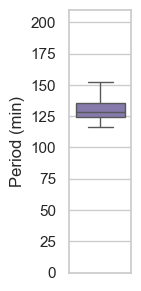

In [58]:
#Plot period

# Filter data
plot_df = my_pyboat_results[
    (my_pyboat_results['power'] > 3)
]


# Average per sample (Position + Condition)
plot_df = plot_df.groupby(['group'], as_index=False)['periods'].mean()

display(plot_df)

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(1.5, 3))

ax = sns.boxplot(y='periods', data=plot_df, color='m', showfliers=False)
#sns.stripplot(plot_df, y='periods', ax=ax, color='None', size=2, linewidth=0.2, edgecolor='gray') 

ax.set(xlabel=None)
ax.set_ylim(0, 210)
#plt.title("Boxplot with Significance", fontsize=14)

plt.ylabel('Period (min)', fontsize=12)



plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/boxplot_editable_period.pdf", format='pdf', transparent=True, dpi=600)

plt.show()


/var/folders/jz/gfj_b5gj1yx0lfb2z6dyr1200000gp/T/ipykernel_25374/1544903812.py:17: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(plot_df, y='amplitude', ax=ax, color='None', size=4, linewidth=0.2, edgecolor='gray')
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 23 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'a', 'd', 'e', 'five', 'four', 'i', 'l', 'm', 'nonmarkingreturn', 'one', 'p', 'par

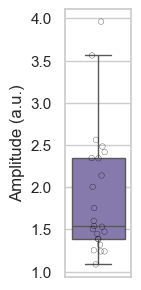

In [59]:
#Plot amplitude

# Filter data
plot_df = my_pyboat_results[
    (my_pyboat_results['power'] > 3)
]


# Average per sample (Position + Condition)
plot_df = plot_df.groupby(['group'], as_index=False)['amplitude'].mean()

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(1.5, 3))

ax = sns.boxplot(y='amplitude', data=plot_df, color='m', showfliers=False)
sns.stripplot(plot_df, y='amplitude', ax=ax, color='None', size=4, linewidth=0.2, edgecolor='gray') 

ax.set(xlabel=None)
#plt.title("Boxplot with Significance", fontsize=14)

plt.ylabel('Amplitude (a.u.)', fontsize=12)



plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/boxplot_editable_amplitude.pdf", format='pdf', transparent=True, dpi=600)

plt.show()

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 32 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'D', 'T', 'a', 'd', 'e', 'eight', 'five', 'four', 'g', 'i', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 39, 55, 68, 71, 72, 74, 76, 79, 80, 81, 85, 86, 87, 88, 237]
INFO:font

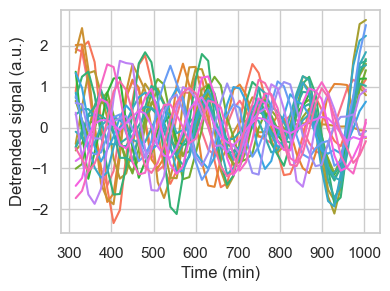

In [60]:
#Plot the intensity

plot_df = my_pyboat_results
plot_df['Intensity_smooth'] = plot_df['Detrended Signal'].rolling(window=5, center=True).mean()


plot_df = plot_df[plot_df['Zeit']>300]
plot_df = plot_df[plot_df['Zeit']<1020]


# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

# Lineplot with multiple lines by 'positiong'
ax = sns.lineplot(
    x='Zeit',
    y='Intensity_smooth',
    hue='group',
    data=plot_df,
    legend=False 
)

# # Optional: overlay the individual points with a scatter style
# sns.stripplot(
#     x='Zeit',
#     y='Intensity_smooth',
#     hue='Position',
#     data=plot_df,
#     dodge=True,            # separate overlapping hues
#     ax=ax,
#     size=4,
#     edgecolor='gray',
#     linewidth=0.5,
#     alpha=0.6,
#     legend=False           # avoid duplicate legend
# )

# Labels


plt.ylabel('Detrended signal (a.u.)', fontsize=12)
plt.xlabel('Time (min)', fontsize=12)

plt.tight_layout()




plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/lineplot_editable_intensity.pdf", format='pdf', transparent=True, dpi=600)

plt.show()

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 32 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'O', 'P', 'R', 'S', 'T', 'a', 'c', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'six', 'space', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 36, 50, 51, 53, 54, 55, 68, 70, 72, 74, 75, 76, 79, 80, 81, 88]
INFO:fontTools.s

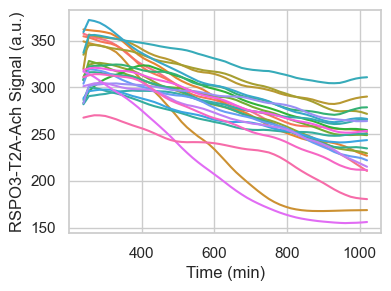

In [61]:
#Plot the raw intensity

plot_raw_df = df
plot_raw_df['Raw_Intensity_smooth'] = df['Intensity'].rolling(window=5, center=True).mean()


plot_raw_df = plot_raw_df[plot_raw_df['Zeit']>230]
plot_raw_df = plot_raw_df[plot_raw_df['Zeit']<1030]


# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

# Lineplot with multiple lines by 'positiong'
ax = sns.lineplot(
    x='Zeit',
    y='Raw_Intensity_smooth',
    hue='group',
    data=plot_raw_df,
    legend=False 
)


# # Optional: overlay the individual points with a scatter style
# sns.stripplot(
#     x='Zeit',
#     y='Intensity_smooth',
#     hue='Position',
#     data=plot_df,
#     dodge=True,            # separate overlapping hues
#     ax=ax,
#     size=4,
#     edgecolor='gray',
#     linewidth=0.5,
#     alpha=0.6,
#     legend=False           # avoid duplicate legend
# )

# Labels


plt.ylabel('RSPO3-T2A-Ach Signal (a.u.)', fontsize=12)
plt.xlabel('Time (min)', fontsize=12)

plt.tight_layout()




plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/lineplot_editable_intensity-raw-smooth.pdf", format='pdf', transparent=True, dpi=600)

plt.show()

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 31 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'D', 'E', 'K', 'a', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 23, 24, 25, 27, 39, 40, 46, 68, 71, 72, 73, 76, 80, 81, 82, 83, 85, 86, 87, 88, 92]
INFO:fontTools.subset:Closed glyph

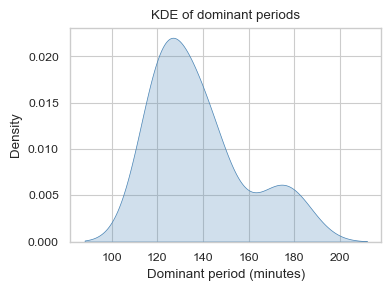

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 35 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'D', 'E', 'K', 'P', 'd', 'e', 'eight', 'f', 'five', 'four', 'h', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 39, 40, 46, 51, 71, 72, 73, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87

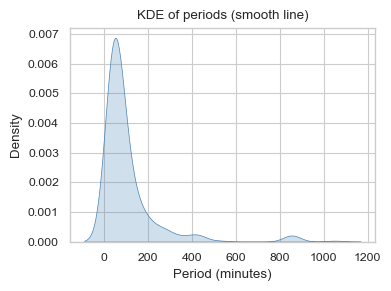

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 28 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'D', 'T', 'a', 'd', 'e', 'eight', 'four', 'g', 'i', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 23, 25, 27, 39, 55, 68, 71, 72, 74, 76, 79, 80, 81, 85, 86, 87, 88, 237]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 28 gly

Filtered data rows: 72
    time     periods     phase  amplitude     power  frequencies  \
72     0  143.045843  1.961378   1.381064  3.848199     0.006991   
73    15  141.121000  2.542424   1.494594  4.427536     0.007086   
74    30  139.343317  3.137084   1.608976  5.039196     0.007177   
75    45  137.712792  3.813176   1.708648  5.682860     0.007261   
76    60  136.229427  4.430453   1.823296  6.352988     0.007341   

    Detrended Signal  Zeit     Position  Experiment          group  \
72         -3.876222     0  Position-02           1  Position-02_1   
73         -2.184958    15  Position-02           1  Position-02_1   
74         -1.694710    30  Position-02           1  Position-02_1   
75          0.149039    45  Position-02           1  Position-02_1   
76          0.644791    60  Position-02           1  Position-02_1   

    Intensity_smooth  
72         -2.313431  
73         -1.998818  
74         -1.392412  
75         -0.161976  
76          0.719982  


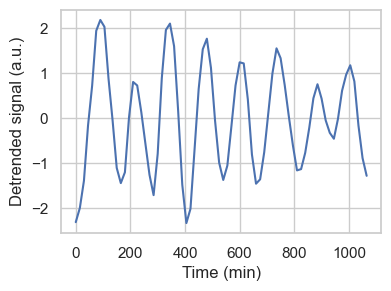

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 30 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'F', 'P', 'S', 'c', 'comma', 'd', 'e', 'f', 'five', 'hyphen', 'i', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'w', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 15, 16, 19, 20, 21, 22, 24, 41, 51, 54, 70, 71, 72, 73, 76, 80, 81, 82, 83, 85, 86, 87, 88, 90]
INFO:fontTools.subset:Closed glyph list over

Filtered data rows: 33
        period  amplitude       power     Position  Experiment          group
34  360.000000   3.165836   10.022518  Position-02           1  Position-02_1
35  270.000000   9.601018   92.179546  Position-02           1  Position-02_1
36  216.000000  24.010405  576.499533  Position-02           1  Position-02_1
37  180.000000   9.371904   87.832591  Position-02           1  Position-02_1
38  154.285714   2.877552    8.280308  Position-02           1  Position-02_1


INFO:fontTools.subset:Retaining 30 glyphs
INFO:fontTools.subset:head subsetting not needed
INFO:fontTools.subset:hhea subsetting not needed
INFO:fontTools.subset:maxp subsetting not needed
INFO:fontTools.subset:OS/2 subsetting not needed
INFO:fontTools.subset:hmtx subsetted
INFO:fontTools.subset:VDMX subsetting not needed
INFO:fontTools.subset:hdmx subsetted
INFO:fontTools.subset:cmap subsetted
INFO:fontTools.subset:fpgm subsetting not needed
INFO:fontTools.subset:prep subsetting not needed
INFO:fontTools.subset:cvt  subsetting not needed
INFO:fontTools.subset:loca subsetting not needed
INFO:fontTools.subset:post subsetted
INFO:fontTools.subset:gasp subsetting not needed
INFO:fontTools.subset:GDEF subsetted
INFO:fontTools.subset:GPOS subsetted
INFO:fontTools.subset:GSUB subsetted
INFO:fontTools.subset:name subsetting not needed
INFO:fontTools.subset:glyf subsetted
INFO:fontTools.subset:head pruned
INFO:fontTools.subset:OS/2 Unicode ranges pruned: [0]
INFO:fontTools.subset:OS/2 CodePage

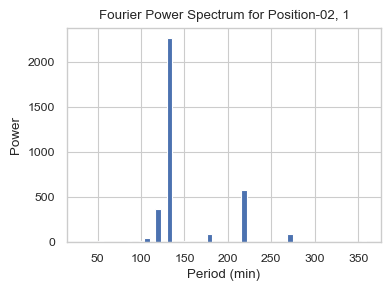

In [62]:

plot_df = my_pyboat_results
sampling_interval = 15  # minutes

fft_results = []

unique_positions = df['group'].unique()

for i in unique_positions:
    subset = plot_df[plot_df['group'] == i]
    subset = subset.sort_values('Zeit')
    subset = subset.dropna(subset=['Intensity_smooth'])
    signal = subset['Intensity_smooth'].values
    
    if len(signal) < 5:
        continue  # skip too short
    
    # FFT
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=sampling_interval)  # cycles per minute
    
    # Only positive frequencies
    idx = np.where(freqs > 0)
    freqs = freqs[idx]
    amplitudes = np.abs(fft_vals[idx])
    power = amplitudes**2
    
    # Sort
    sort_idx = np.argsort(freqs)
    freqs = freqs[sort_idx]
    amplitudes = amplitudes[sort_idx]
    power = power[sort_idx]
    
    # Check duration, exclude first 2 harmonics if needed
    total_duration = subset['Zeit'].max() - subset['Zeit'].min()
    if np.isclose(total_duration, 1065):
        freqs = freqs[2:]
        amplitudes = amplitudes[2:]
        power = power[2:]
    
    # Period
    periods = 1 / freqs

    position = subset['Position'].iloc[0]
    experiment = subset['Experiment'].iloc[0]
    
    # Store
    temp_df = pd.DataFrame({
        'period': periods,
        'amplitude': amplitudes,
        'power': power,
        'Position': position,
        'Experiment': experiment,
        'group': i
    })
    fft_results.append(temp_df)

fft_df = pd.concat(fft_results, ignore_index=True)

fft_df.to_csv('/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/fft-out.csv', index=True) 


##### Plot combined histogram
####### plot density of dominant periods #############
# Find dominant period per signal
dominant_periods = fft_df.loc[fft_df.groupby(['Position', 'Experiment'])['amplitude'].idxmax()]

# Plot as KDE
plt.figure(figsize=(4,3))
sns.kdeplot(dominant_periods['period'], fill=True, color='steelblue', linewidth=0.5)
plt.xlabel('Dominant period (minutes)')
plt.title('KDE of dominant periods')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/FFT-density-dominant-period.pdf", format='pdf', transparent=True, dpi=600)

plt.show()



####### Plot KDE plot ###############

plt.figure(figsize=(4,3))
sns.kdeplot(fft_df['period'], fill=True, color='steelblue', linewidth=0.5)
plt.xlabel('Period (minutes)')
plt.ylabel('Density')
plt.title('KDE of periods (smooth line)')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/FFT-KDE_combined.pdf", format='pdf', transparent=True, dpi=600)

plt.show()




########### Pick example track #########

example_position = 'Position-02'
example_experiment = 1


##### plot lineplot of smoothened detrended data ######

# Filter to one example
example_raw_data = plot_df[
    (plot_df['Position'] == example_position) &
    (plot_df['Experiment'] == example_experiment)
]

print(f"Filtered data rows: {len(example_raw_data)}")
print(example_raw_data.head())

sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

# Lineplot with multiple lines by 'positiong'
ax = sns.lineplot(
    x='Zeit',
    y='Intensity_smooth',
    data=example_raw_data,
    legend=False 
)

plt.ylabel('Detrended signal (a.u.)', fontsize=12)
plt.xlabel('Time (min)', fontsize=12)

plt.tight_layout()




plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/lineplot_editable_intensity_example.pdf", format='pdf', transparent=True, dpi=600)

plt.show()


##### Plot power spectrum of FT ######

# Filter to one example
example_data = fft_df[
    (fft_df['Position'] == example_position) &
    (fft_df['Experiment'] == example_experiment)
]

print(f"Filtered data rows: {len(example_data)}")
print(example_data.head())

# Sort by period
example_data = example_data.sort_values('period')


plt.figure(figsize=(4,3))

plt.hist(
    example_data['period'],
    bins=50,
    weights=example_data['power'],
    alpha=1.0,
    histtype='stepfilled'
)

plt.xlabel('Period (min)')
plt.ylabel('Power')
plt.title(f'Fourier Power Spectrum for {example_position}, {example_experiment}')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/FFT-histogram-one-example.pdf", format='pdf', transparent=True, dpi=600)

plt.show()





INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 35 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'P', 'S', 'a', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 19, 20, 21, 22, 23, 24, 25, 27, 36, 51, 54, 68, 70, 71, 72, 74, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90]

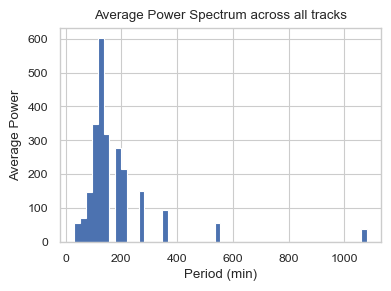

In [63]:

########### plot average power spectrum ##########

sampling_interval = 15  # minutes between samples
N = 72  # force signals to this length

all_power_spectra = []

unique_positions = df['group'].unique()

for i in unique_positions:
    subset = plot_df[plot_df['group'] == i]
    subset = subset.sort_values('Zeit')
    subset = subset.dropna(subset=['Intensity_smooth'])
    signal = subset['Intensity_smooth'].values
    
    signal = signal - np.mean(signal)  # detrend mean

    # Pad or trim signal to common length N
    if len(signal) < N:
        signal = np.pad(signal, (0, N - len(signal)), 'constant')
    else:
        signal = signal[:N]

    # FFT
    fft_vals = np.fft.fft(signal)
    power = np.abs(fft_vals)**2
    
    # positive frequencies
    freqs = np.fft.fftfreq(N, d=sampling_interval)
    idx = freqs > 0
    power = power[idx]
    freqs = freqs[idx]

    all_power_spectra.append(power)

# Now compute average
all_power_spectra = np.array(all_power_spectra)
mean_power_spectrum = np.mean(all_power_spectra, axis=0)

# Convert to periods
periods = 1 / freqs

# Optional: smooth
smoothed_power = gaussian_filter1d(mean_power_spectrum, sigma=2)

# Plot
plt.figure(figsize=(4,3))

plt.hist(
    periods,
    bins=50,
    weights=smoothed_power,
    alpha=1.0,
    histtype='stepfilled'
)

plt.xlabel('Period (min)')
plt.ylabel('Average Power')
plt.title(f'Average Power Spectrum across all tracks')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Arial'
sns.set_context('paper')

# Save as pdf (editable in Illustrator)
plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/RSPO3-imaging/FFT-histogram-average.pdf", format='pdf', transparent=True, dpi=600)

plt.show()
